> **Nota**: este notebook documenta el desarrollo exploratorio del pipeline
> ARIMA/SARIMAX y su auditoria (fugas de informacion corregidas, ver
> `README.md`). Las salidas de las celdas reflejan una corrida anterior a
> la version final. Para reproducir los resultados finales (los que se
> reportan en `docs/analisis_resultados.md`), correr
> `src/models/arima/run_pipeline.sh` directamente -- es la fuente de
> verdad, mas rapida de auditar y ya incluye reanudacion automatica.


### Ejecución y análisis de los modelos ARIMA

> **Nota de auditoría (2026-07-14):** se corrigieron 3 problemas en `forecasting_arima_utils.py` (afectan a ARIMAX_H*/SARIMAX_H*):
>
> 1. Las exógenas desplazadas (`x_desplazada`/`*_x_h`) no se escalaban — se mezclaba radiación solar en W/m² con variables cíclicas en [-1,1] sin normalizar. Síntoma: SARIMA (sin exógenas) superaba a SARIMAX en los 3 horizontes, señal de mal condicionamiento numérico. Corregido en `segmentar_datos`.
> 2. Desfase de 1 hora entre `pred` y `real` en la rama con exógenas del walk-forward (`idx_real` usaba `inicio + h` en vez de `inicio + h - 1`, confirmado empíricamente contra las predicciones ya generadas). Impacto en las métricas: mínimo (la temperatura cambia poco en 1h), pero incorrecto en principio.
> 3. La búsqueda de hiperparámetros volvió a seleccionar por AIC en vez de por el RMSE de validación ya calculado (regresión de una corrección anterior). Corregido de nuevo.
>
> **Hay que volver a correr las celdas 5 (modelos base), 9 (tuning) y 13 (predicciones walk-forward) para que los resultados reflejen las correcciones** — los outputs que ves debajo de esas celdas son de la corrida anterior (sin corregir) y quedan solo como referencia histórica del problema encontrado.


In [1]:
# Librerias
from pathlib import Path
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import load
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import sys
sys.path.append("../../src/models/modelosARIMA")

from forecasting_arima_utils import (
    cargar_modelo,
    mostrar_resultados_modelo,
    calcular_metricas,
    grafico_predicciones_ci
)

### 1. Feature engineering

INFO: Cargando datos desde: ..\..\data\mdt_feature_store_2008.parquet...
INFO: Memoria inicial: 140.04 MB
INFO: Memoria optimizada: 118.07 MB
INFO: Base de datos cargada: 959760 filas
INFO: Nulos en base agrupada: 0 obs (0.0%)
INFO: Distribución de segmentos -> Train: 122664 (76.7%) | Val: 17520 (11.0%) | Test: 19704 (12.3%)
INFO: Analizando estacionariedad de la serie de entrenamiento...
INFO: ADF [temperatura (train)]: p-valor=0.0000 -> Estacionaria


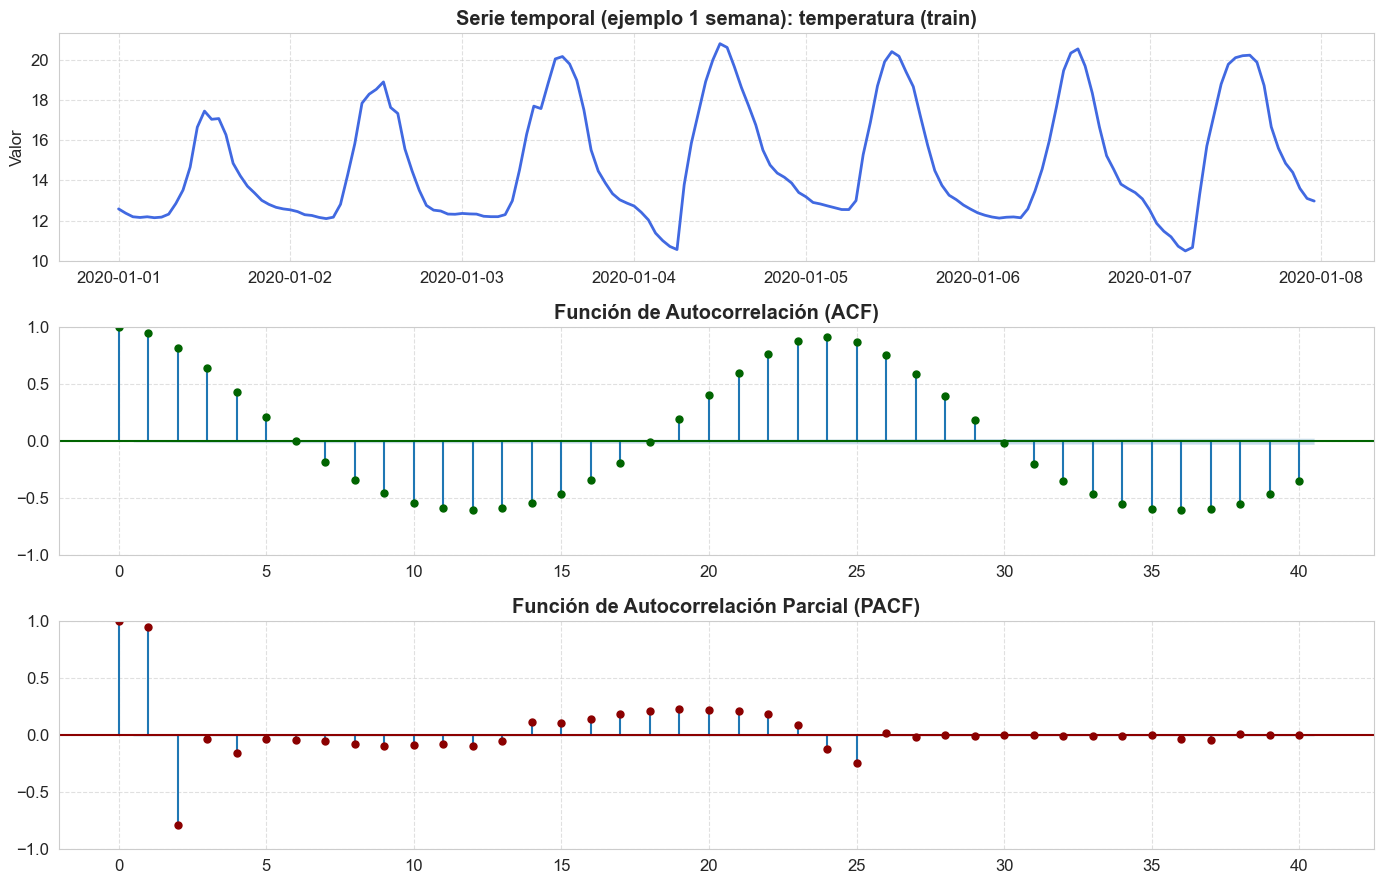

INFO: Feature store guardado en: ..\..\results\modelosARIMA\feature_engineering\feature_engineering.pkl ✅


CPU times: total: 2min 47s
Wall time: 49.1 s


In [2]:
%%time
# Ejecutar script de feature engineering
%run ../../src/models/modelosARIMA/feature_engineering.py

### 2. Entrenamiento de modelos base (sin búsqueda de hiperparámetros)

In [3]:
%%time
# Ejecutar script de entrenamiento de modelos base
%run ../../src/models/modelosARIMA/train_modelos_base.py

INFO: Feature store cargado desde: ..\..\results\modelosARIMA\feature_engineering\feature_engineering.pkl
INFO: Serie estacionaria: True -> d=0
INFO: Entrenando 8 tipos de modelo: ['ARIMA', 'SARIMA', 'ARIMAX_H3', 'ARIMAX_H48', 'ARIMAX_H72', 'SARIMAX_H3', 'SARIMAX_H48', 'SARIMAX_H72']
INFO: Modelo ARIMA guardado en: ..\..\modelos\modelosARIMA\modelo_arima_base.pkl
INFO: Modelo SARIMA guardado en: ..\..\modelos\modelosARIMA\modelo_sarima_base.pkl
INFO: Modelo ARIMAX_H3 guardado en: ..\..\modelos\modelosARIMA\modelo_arimax_h3_base.pkl
INFO: Modelo ARIMAX_H48 guardado en: ..\..\modelos\modelosARIMA\modelo_arimax_h48_base.pkl
INFO: Modelo ARIMAX_H72 guardado en: ..\..\modelos\modelosARIMA\modelo_arimax_h72_base.pkl
INFO: Modelo SARIMAX_H3 guardado en: ..\..\modelos\modelosARIMA\modelo_sarimax_h3_base.pkl
INFO: Modelo SARIMAX_H48 guardado en: ..\..\modelos\modelosARIMA\modelo_sarimax_h48_base.pkl
INFO: Modelo SARIMAX_H72 guardado en: ..\..\modelos\modelosARIMA\modelo_sarimax_h72_base.pkl


CPU times: total: 3.56 s
Wall time: 23min 58s


### 3. Resultados de los modelos base (baseline)

In [4]:
%%time
# Cargar y mostrar resultados de los modelos base
HORIZONTES = [3, 48, 72]
TIPOS_MODELOS = ["ARIMA", "SARIMA"]
TIPOS_MODELOS += [f"{m}_H{h}" for m in ["ARIMAX", "SARIMAX"] for h in HORIZONTES]

FILE_PATH = Path("../../results/modelosARIMA/feature_engineering/feature_engineering.pkl")
OUTPUT_DIR = Path("../../modelos/modelosARIMA/")

feature_data = load(FILE_PATH)
train_y = feature_data["train_y"]
train_x_h = feature_data["train_x_h"]
train_X = feature_data["train_x"]
val_y = feature_data["val_y"]
val_x_h = feature_data["val_x_h"]
val_x = feature_data["val_x"]

for tipo in TIPOS_MODELOS:
    # CORRECCIÓN (auditoría 2026-07-14): antes se recargaba SIEMPRE con
    # `train_X` (exógena contemporánea), incluso para los tipos "_H*", que
    # se ajustaron con `train_x_h[h]` (exógena desplazada por horizonte).
    # cargar_modelo() reconstruye el estado del modelo vía apply(); pasarle
    # el exog equivocado no truena, pero corrompe el estado usado para el
    # resumen/RMSE que se imprime a continuación (no afectaba las
    # predicciones finales de predicciones_tuning.py, que ya cargaban bien).
    if "_H" in tipo:
        h = int(tipo.split("_H")[1])
        exog_para_cargar = train_x_h[h]
    else:
        h = None
        exog_para_cargar = train_X

    modelo = cargar_modelo(OUTPUT_DIR / f"modelo_{tipo.lower()}_base.pkl", train_y, exog_para_cargar)
    print(f"\n------ {tipo} BASELINE ------")
    if h is not None:
        mostrar_resultados_modelo(modelo=modelo, y_val=val_y, exog=val_x_h[h])
    else:
        # ARIMA y SARIMA no usan exógenas ni desplazamiento.
        mostrar_resultados_modelo(modelo=modelo, y_val=val_y)

    # Liberar memoria
    del modelo
    gc.collect()



------ ARIMA BASELINE ------


INFO: Parámetros: p=1, d=0, q=1
INFO: AIC: 292758.16, BIC: 292797.03, RMSE: 3.1590


                               SARIMAX Results                                
Dep. Variable:       temperaturaMedia   No. Observations:               122664
Model:                 ARIMA(1, 0, 1)   Log Likelihood             -146375.080
Date:                Tue, 14 Jul 2026   AIC                         292758.160
Time:                        00:36:15   BIC                         292797.029
Sample:                    01-04-2008   HQIC                        292769.849
                         - 12-31-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.9561      0.064    235.317      0.000      14.831      15.081
ar.L1          0.9224      0.001    646.215      0.000       0.920       0.925
ma.L1          0.6669      0.002    346.949      0.0

INFO: Parámetros: p=1, d=0, q=1
INFO: AIC: 172309.07, BIC: 172367.38, RMSE: 2.4080


                                     SARIMAX Results                                      
Dep. Variable:                   temperaturaMedia   No. Observations:               122664
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood              -86148.537
Date:                            Tue, 14 Jul 2026   AIC                         172309.075
Time:                                    00:36:49   BIC                         172367.378
Sample:                                01-04-2008   HQIC                        172326.607
                                     - 12-31-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0067      0.000     17.949      0.000       0.006       0.007
ar.L1          0.8550      0.001   

...

                                     SARIMAX Results                                      
Dep. Variable:                   temperaturaMedia   No. Observations:               122664
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood             -568937.318
Date:                            Tue, 14 Jul 2026   AIC                        1137916.636
Time:                                    00:38:41   BIC                        1138120.698
Sample:                                01-04-2008   HQIC                       1137978.001
                                     - 12-31-2021                                         
Covariance Type:                              opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept               0.0014      0.456      0.003      0.997      -0.892       0.895
humedadR

INFO: Parámetros: p=1, d=0, q=1
INFO: AIC: 921253.81, BIC: 921457.88, RMSE: 1.5051


                                     SARIMAX Results                                      
Dep. Variable:                   temperaturaMedia   No. Observations:               122664
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood             -460605.907
Date:                            Tue, 14 Jul 2026   AIC                         921253.814
Time:                                    00:39:12   BIC                         921457.875
Sample:                                01-04-2008   HQIC                        921315.178
                                     - 12-31-2021                                         
Covariance Type:                              opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept               0.0003      0.538      0.001      1.000      -1.053       1.054
humedadR

INFO: Parámetros: p=1, d=0, q=1
INFO: AIC: 776252.00, BIC: 776456.06, RMSE: 1.5734


                                     SARIMAX Results                                      
Dep. Variable:                   temperaturaMedia   No. Observations:               122664
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood             -388104.998
Date:                            Tue, 14 Jul 2026   AIC                         776251.996
Time:                                    00:39:43   BIC                         776456.058
Sample:                                01-04-2008   HQIC                        776313.361
                                     - 12-31-2021                                         
Covariance Type:                              opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept               0.0005      0.428      0.001      0.999      -0.839       0.839
humedadR

### 4. Búsqueda de hiperparámetros (tuning)

In [5]:
%%time
# Ejecutar script de búsqueda de hiperparámetros
%run ../../src/models/modelosARIMA/tuning_modelos.py

INFO: Feature store cargado desde: ..\..\results\modelosARIMA\feature_engineering\feature_engineering.pkl
INFO: Serie estacionaria: True -> d=0
INFO: Modelo guardado exitosamente en: ..\..\modelos\modelosARIMA\tuning\modelo_arima_tuning.pkl
C:\Users\horus\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: method_kwargs. After release 0.14, this will raise.
  warnings.warn(
C:\Users\horus\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
INFO: Modelo guardado exitosamente en: ..

CPU times: total: 1h 35min 4s
Wall time: 7h 2min 20s


### 5. Resultados de los modelos con tuning

In [6]:
%%time
# Cargar y mostrar resultados de los modelos con tuning
HORIZONTES = [3, 48, 72]
TIPOS_MODELOS = ["ARIMA", "SARIMA"]
TIPOS_MODELOS += [f"{m}_H{h}" for m in ["ARIMAX", "SARIMAX"] for h in HORIZONTES]

FILE_PATH = Path("../../results/modelosARIMA/feature_engineering/feature_engineering.pkl")
OUTPUT_DIR = Path("../../modelos/modelosARIMA/tuning/")

feature_data = load(FILE_PATH)
train_y = feature_data["train_y"]
train_x_h = feature_data["train_x_h"]
train_X = feature_data["train_x"]
val_y = feature_data["val_y"]
val_x_h = feature_data["val_x_h"]
val_x = feature_data["val_x"]

for tipo in TIPOS_MODELOS:
    # Ver nota de la celda anterior: usar la exógena correcta (desplazada
    # por horizonte para los tipos "_H*") al reconstruir el modelo.
    if "_H" in tipo:
        h = int(tipo.split("_H")[1])
        exog_para_cargar = train_x_h[h]
    else:
        h = None
        exog_para_cargar = train_X

    modelo = cargar_modelo(OUTPUT_DIR / f"modelo_{tipo.lower()}_tuning.pkl", train_y, exog_para_cargar)
    print(f"\n------ {tipo} TUNING ------")
    if h is not None:
        mostrar_resultados_modelo(modelo=modelo, y_val=val_y, exog=val_x_h[h])
    else:
        # ARIMA y SARIMA no usan exógenas ni desplazamiento.
        mostrar_resultados_modelo(modelo=modelo, y_val=val_y)

    # Liberar memoria
    del modelo
    gc.collect()



------ ARIMA TUNING ------


INFO: Parámetros: p=2, d=0, q=2
INFO: AIC: 242992.34, BIC: 243050.65, RMSE: 3.1582


                               SARIMAX Results                                
Dep. Variable:       temperaturaMedia   No. Observations:               122664
Model:                 ARIMA(2, 0, 2)   Log Likelihood             -121490.172
Date:                Tue, 14 Jul 2026   AIC                         242992.343
Time:                        07:50:16   BIC                         243050.646
Sample:                    01-04-2008   HQIC                        243009.876
                         - 12-31-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.9562      0.017    865.515      0.000      14.922      14.990
ar.L1          1.8254      0.002    784.884      0.000       1.821       1.830
ar.L2         -0.9015      0.002   -426.747      0.0

INFO: Parámetros: p=2, d=0, q=1
INFO: AIC: 172023.18, BIC: 172091.20, RMSE: 2.4640


                                     SARIMAX Results                                      
Dep. Variable:                   temperaturaMedia   No. Observations:               122664
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 24)   Log Likelihood              -86004.591
Date:                            Tue, 14 Jul 2026   AIC                         172023.181
Time:                                    07:50:49   BIC                         172091.202
Sample:                                01-04-2008   HQIC                        172043.636
                                     - 12-31-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0070      0.000     19.405      0.000       0.006       0.008
ar.L1          0.9915      0.006   

...

                                      SARIMAX Results                                       
Dep. Variable:                     temperaturaMedia   No. Observations:               122664
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 24)   Log Likelihood             -545615.844
Date:                              Tue, 14 Jul 2026   AIC                        1091277.689
Time:                                      07:52:42   BIC                        1091501.185
Sample:                                  01-04-2008   HQIC                       1091344.898
                                       - 12-31-2021                                         
Covariance Type:                                opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept               0.0022      0.485      0.004      0.996      -0.948     

INFO: Parámetros: p=2, d=0, q=2
INFO: AIC: 1027990.57, BIC: 1028214.07, RMSE: 1.5335


                                      SARIMAX Results                                       
Dep. Variable:                     temperaturaMedia   No. Observations:               122664
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 24)   Log Likelihood             -513972.287
Date:                              Tue, 14 Jul 2026   AIC                        1027990.574
Time:                                      07:53:14   BIC                        1028214.070
Sample:                                  01-04-2008   HQIC                       1028057.783
                                       - 12-31-2021                                         
Covariance Type:                                opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept               0.0005      0.573      0.001      0.999      -1.123     

INFO: Parámetros: p=2, d=0, q=1
INFO: AIC: 849109.19, BIC: 849322.97, RMSE: 1.6016


                                     SARIMAX Results                                      
Dep. Variable:                   temperaturaMedia   No. Observations:               122664
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 24)   Log Likelihood             -424532.597
Date:                            Tue, 14 Jul 2026   AIC                         849109.193
Time:                                    07:53:45   BIC                         849322.972
Sample:                                01-04-2008   HQIC                        849173.480
                                     - 12-31-2021                                         
Covariance Type:                              opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept               0.0007      0.438      0.002      0.999      -0.858       0.859
humedadR

### 5. Predicciones walk-forward (general + por estación)

In [7]:
%%time
# Ejecutar script de predicciones de los modelos de tuning
%run ../../src/models/modelosARIMA/predicciones_tuning.py

INFO: Feature store cargado desde: ..\..\results\modelosARIMA\feature_engineering\feature_engineering.pkl
INFO: [general] Rango a recorrer: 2022-01-01 00:00:00 -> 2026-03-31 23:00:00 (37224 horas)
Rolling forecast tuning [general]: 100%|███████████████| 37221/37221 [43:30<00:00, 14.26hora/s, horizontes_activos=[3]]
INFO: Predicciones de tuning guardadas en: ..\..\results\modelosARIMA\prediciones\predicciones_tuning.parquet ✅
INFO: [general] Predicciones generadas: 446196 filas -> ..\..\results\modelosARIMA\prediciones\predicciones_tuning.parquet
INFO: Cargando datos desde: ..\..\data\mdt_feature_store_2008.parquet...
INFO: Memoria inicial: 140.04 MB
INFO: Memoria optimizada: 118.07 MB
INFO: Estaciones a procesar (6): ['Belisario', 'Carapungo', 'Cotocollao', 'ElCamal', 'LosChillos', 'Tumbaco']
INFO: Predicciones combinadas de todas las estaciones guardadas en: ..\..\results\modelosARIMA\prediciones\predicciones_tuning_estaciones.parquet


CPU times: total: 44min 16s
Wall time: 1h 54min 46s


### 6. Análisis de resultados

Primero la vista general (promedio entre estaciones), luego por estación.

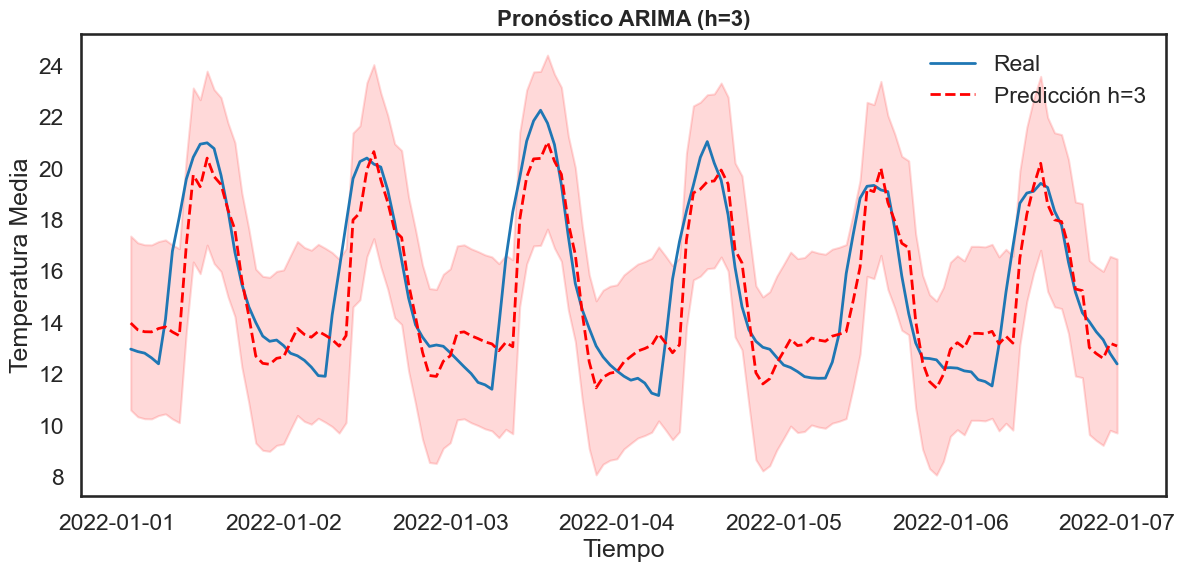

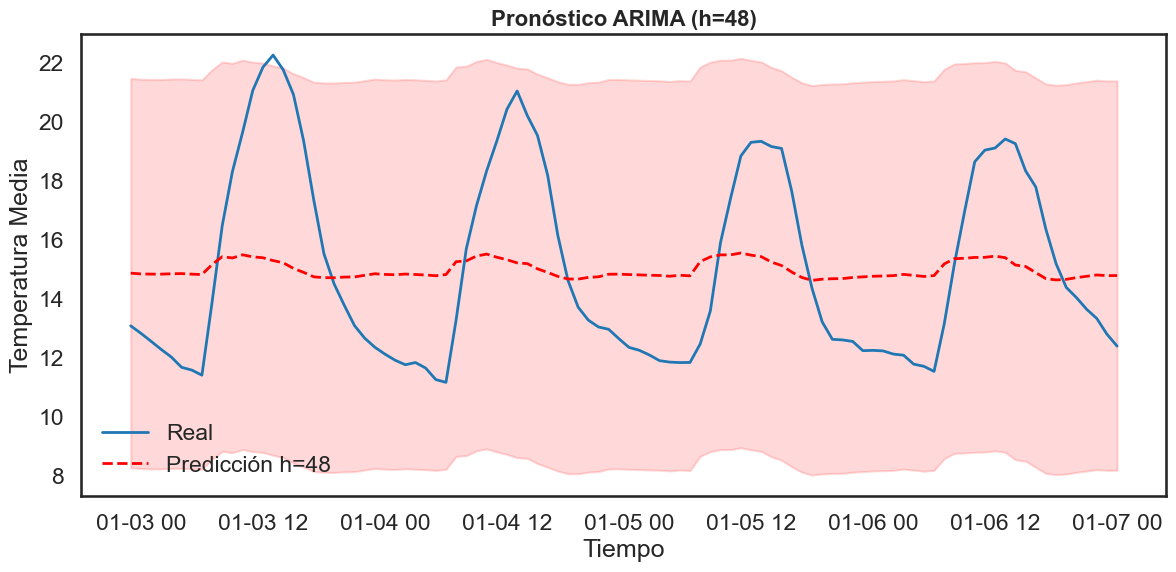

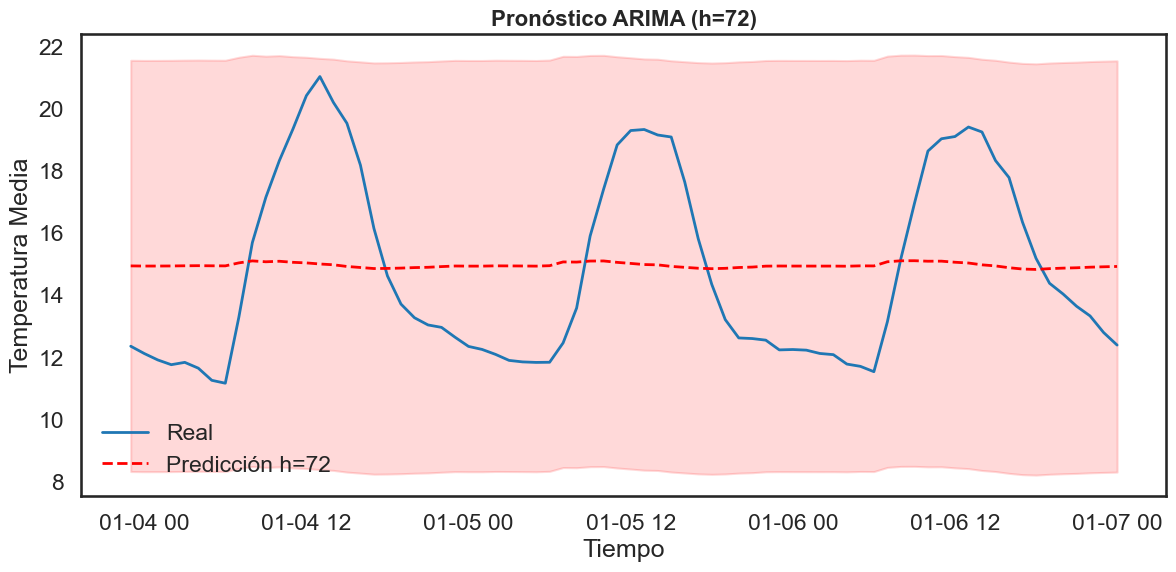

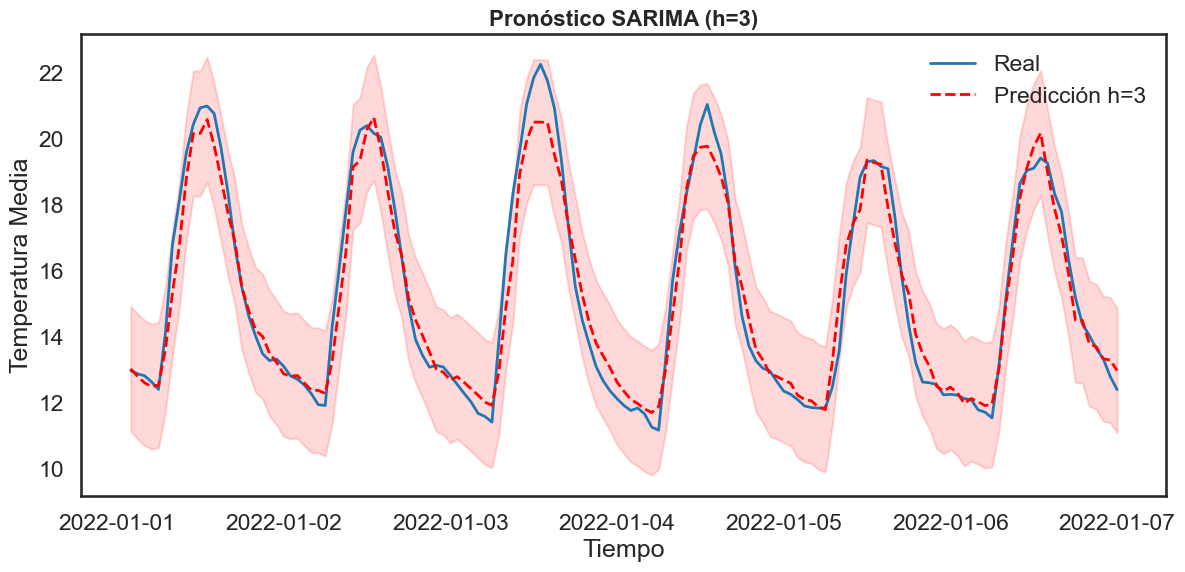

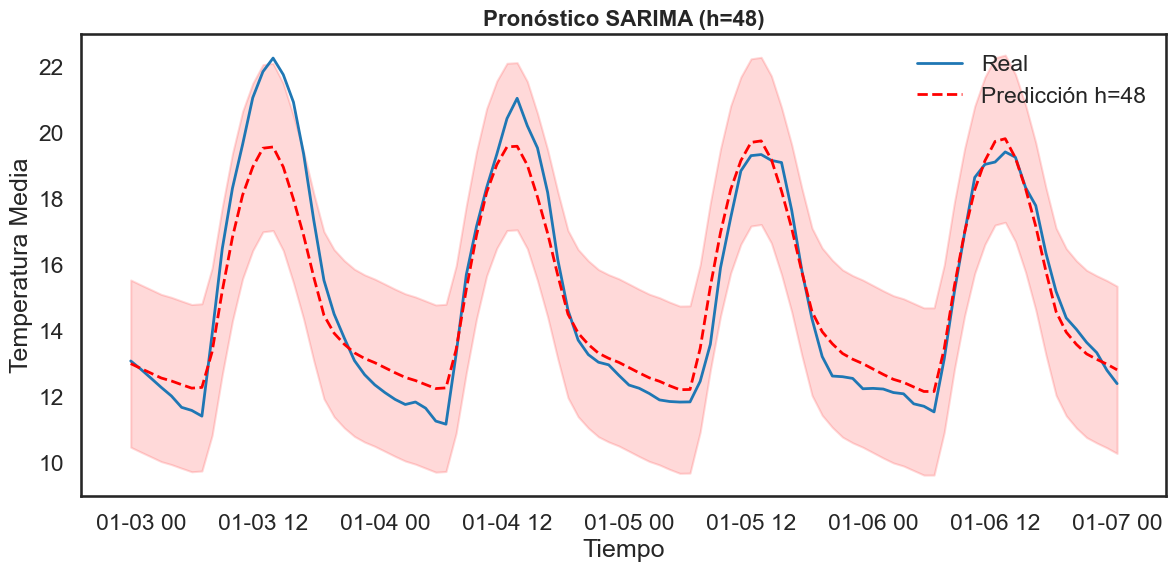

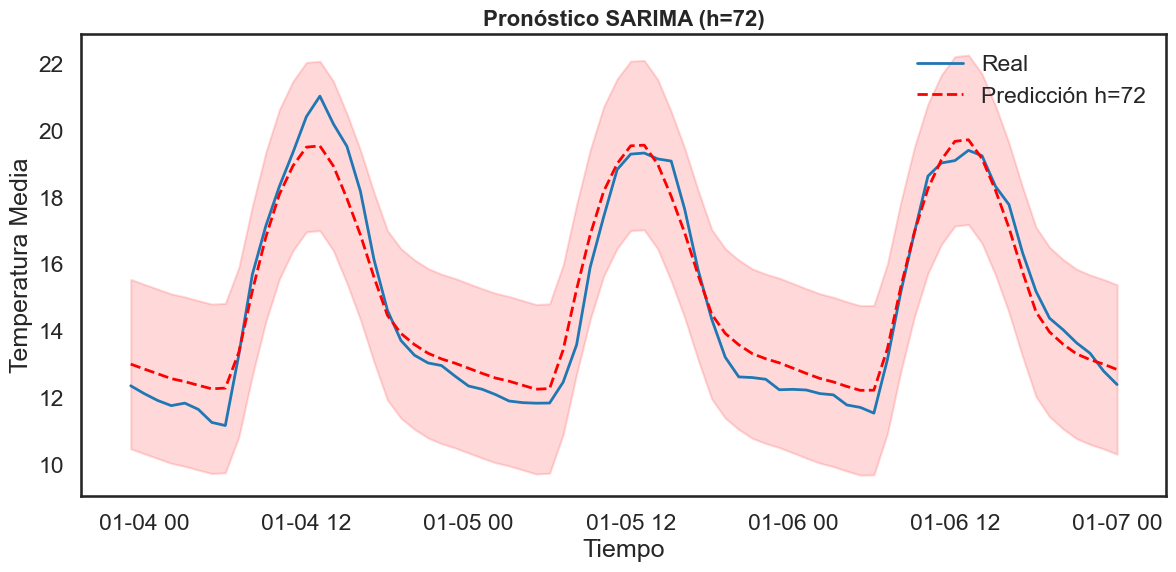

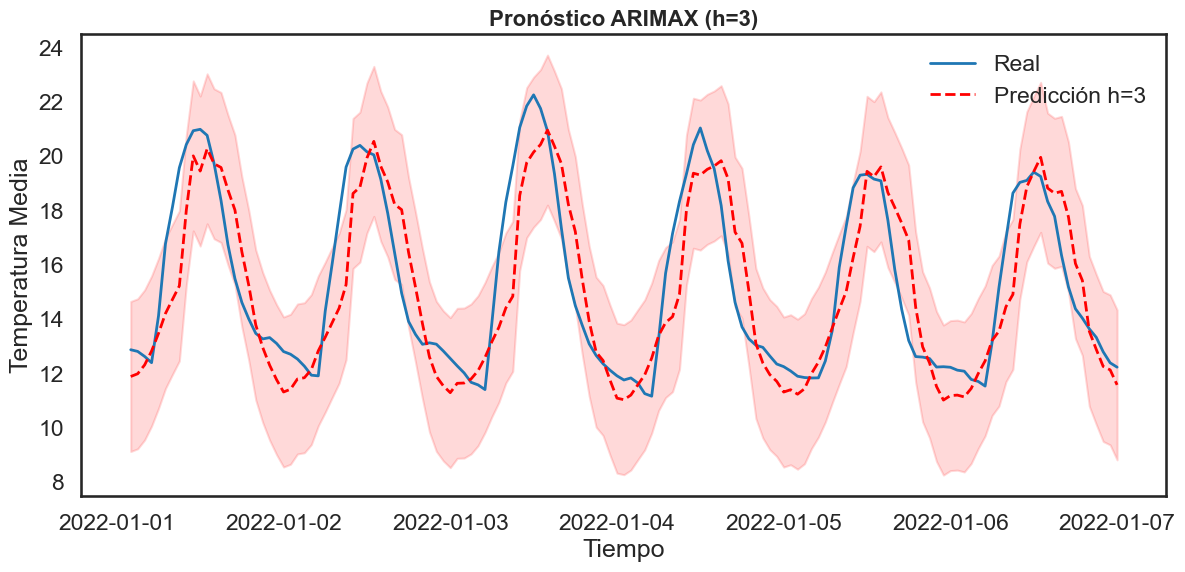

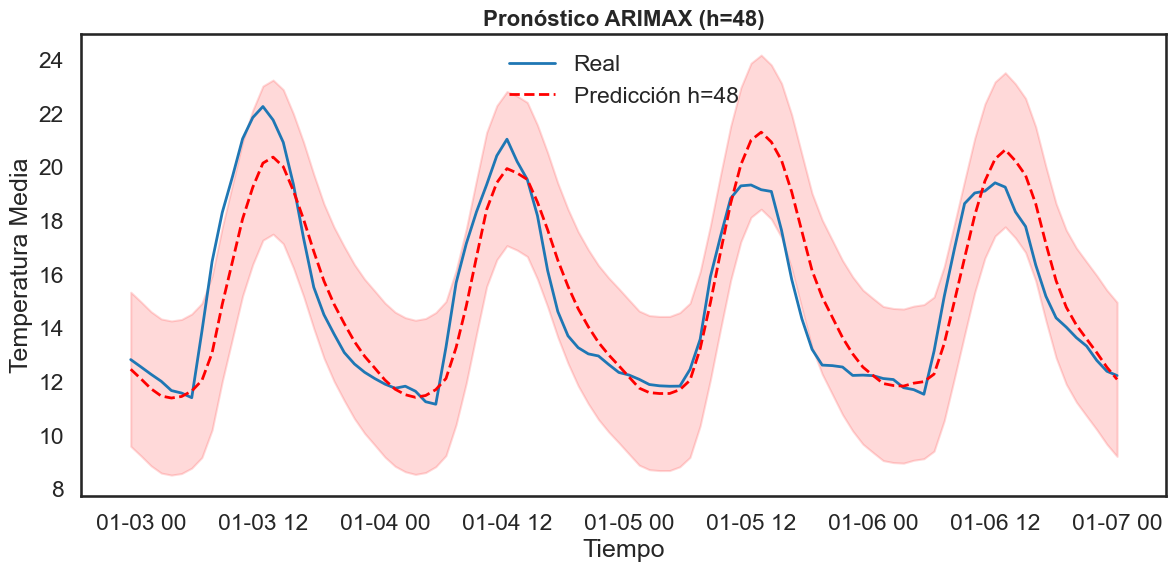

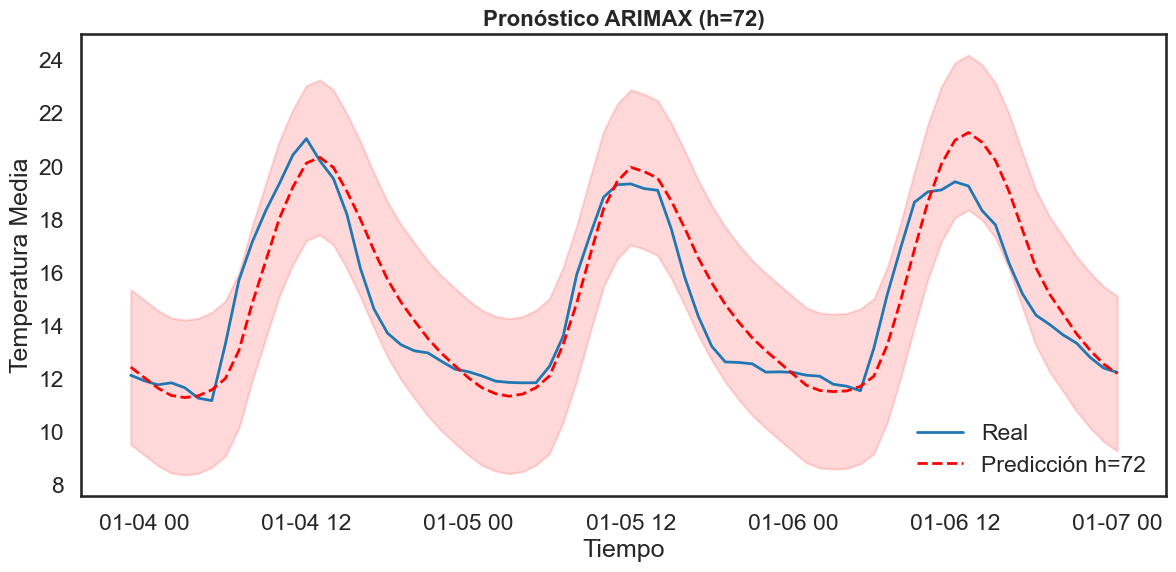

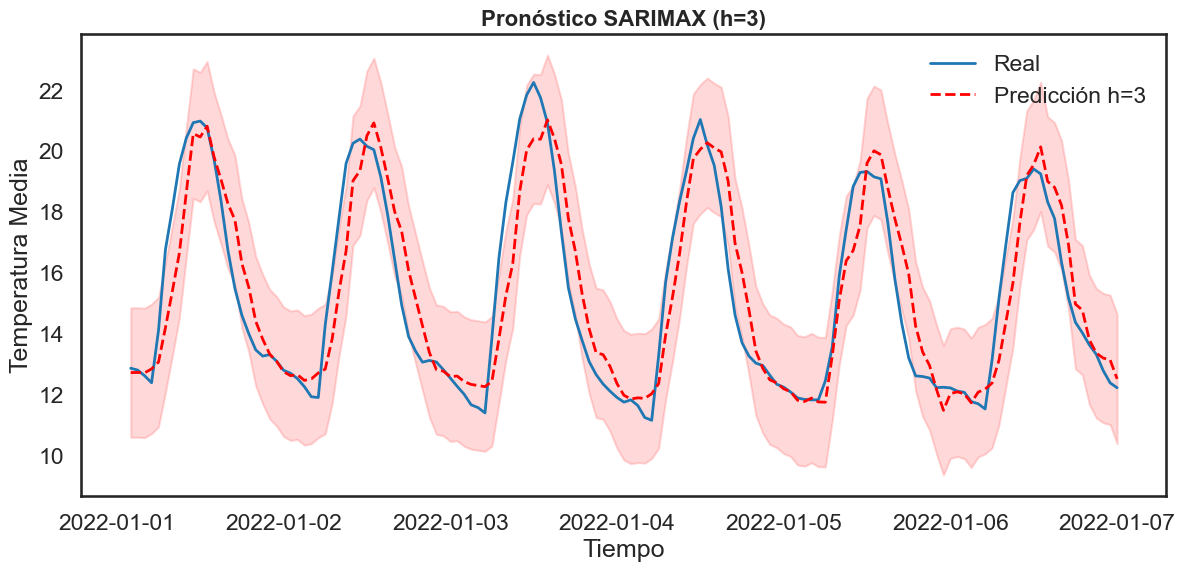

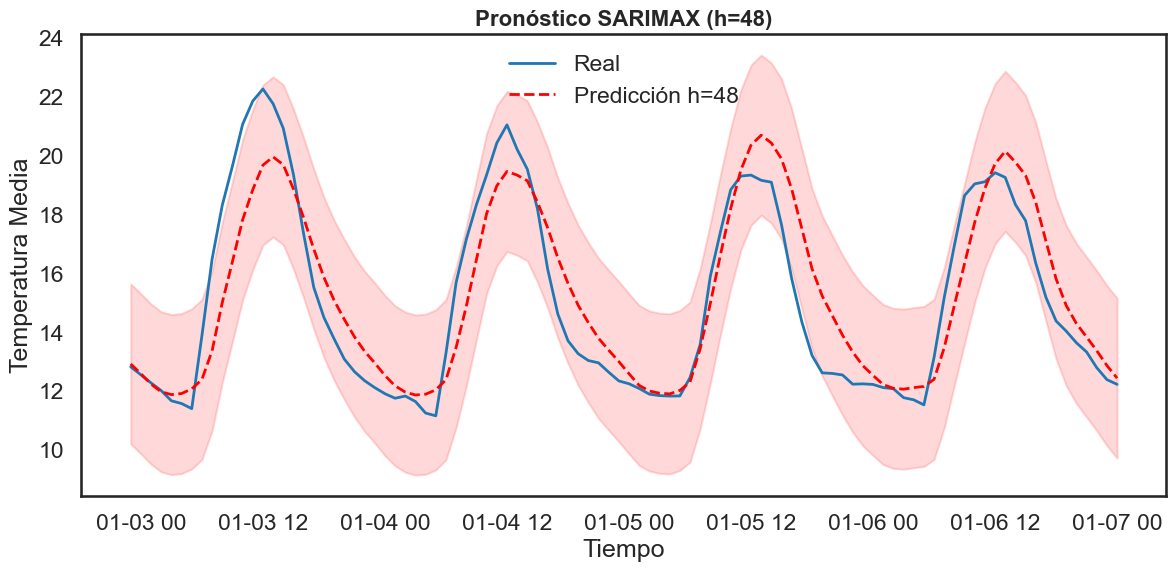

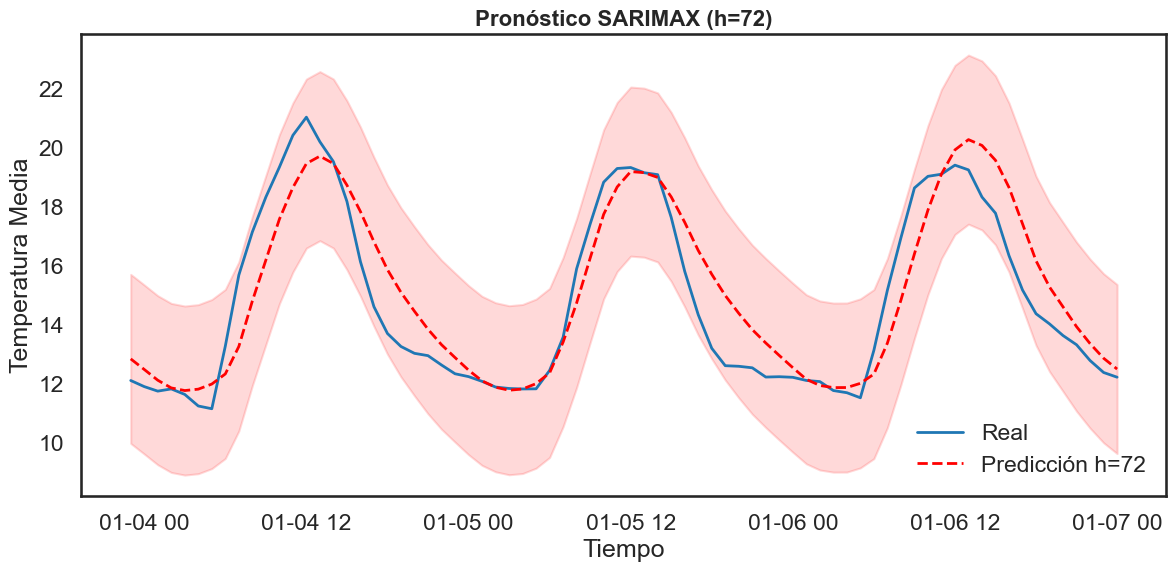

CPU times: total: 2.11 s
Wall time: 2.17 s


,modelo,horizonte,MAE,RMSE,MAPE (%),R2
0,arima,3,1.313358,1.680154,8.872057,0.724413
1,arima,48,2.570324,3.036704,17.016769,0.099761
2,arima,72,2.699020,3.179567,17.862779,0.012797
3,arimax,3,1.404845,1.830851,9.092705,0.672759
4,arimax,48,1.444175,1.872561,9.374005,0.657685
5,arimax,72,1.467428,1.897622,9.522404,0.648363
6,sarima,3,0.665344,0.937325,4.324711,0.914229
7,sarima,48,0.955247,1.276375,6.304454,0.840959
8,sarima,72,0.970726,1.296179,6.404840,0.835941
9,sarimax,3,1.169166,1.564096,7.509815,0.761170


In [8]:
%%time
# --- Análisis general (promedio entre estaciones) ---
df_pred = pd.read_parquet('../../results/modelosARIMA/prediciones/predicciones_tuning.parquet')

for modelo in ['arima', 'sarima', 'arimax', 'sarimax']:
    grafico_predicciones_ci(df_pred, modelo=modelo, fecha_inicio="2022-01-01", fecha_fin="2022-01-07")

metricas_general = calcular_metricas(df_pred)
metricas_general

In [9]:
%%time
# --- Análisis por estación ---
df_pred_estaciones = pd.read_parquet(
    '../../results/modelosARIMA/prediciones/predicciones_tuning_estaciones.parquet'
)

metricas_por_estacion = calcular_metricas(df_pred_estaciones, estaciones=True)
metricas_por_estacion

CPU times: total: 2 s
Wall time: 1.62 s


,modelo,horizonte,estacion,MAE,RMSE,MAPE (%),R2
0,arima,3,Belisario,1.509455,1.877398,11.438772,0.621236
1,arima,3,Carapungo,1.416818,1.798288,9.519834,0.675076
2,arima,3,Cotocollao,1.516877,1.886079,11.049018,0.592940
3,arima,3,ElCamal,1.394955,1.754495,10.188841,0.609344
4,arima,3,LosChillos,1.804148,2.411787,11.002600,0.610222
...,...,...,...,...,...,...,...
67,sarimax,72,Carapungo,1.523679,1.984241,9.839679,0.604331
68,sarimax,72,Cotocollao,1.561730,1.963939,11.037040,0.558523
69,sarimax,72,ElCamal,1.440075,1.860124,10.064689,0.560711
70,sarimax,72,LosChillos,1.918756,2.540998,11.145575,0.567218


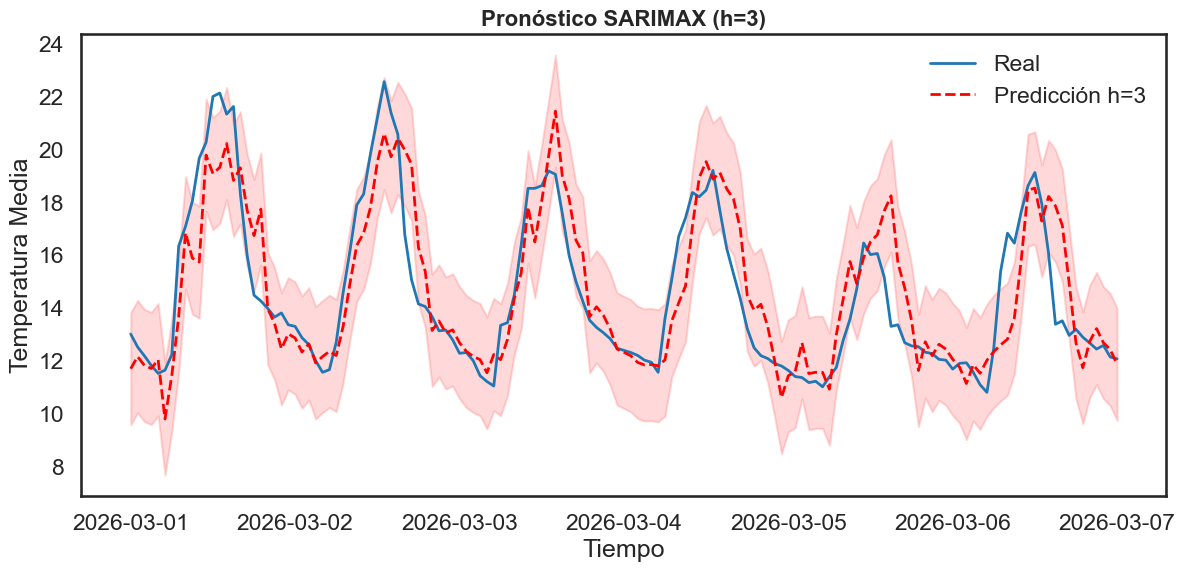

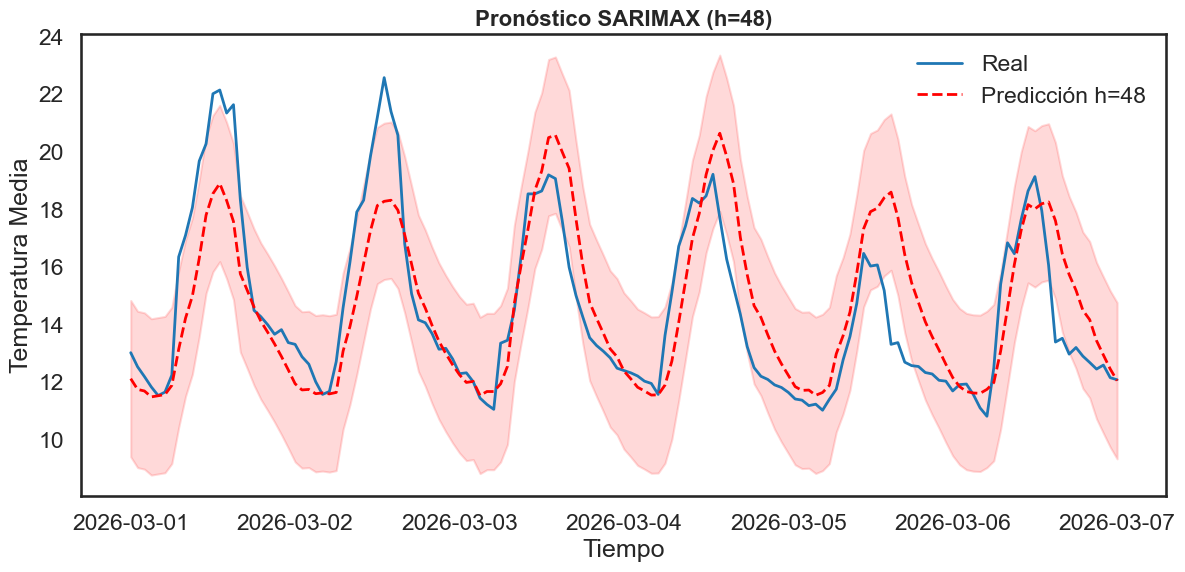

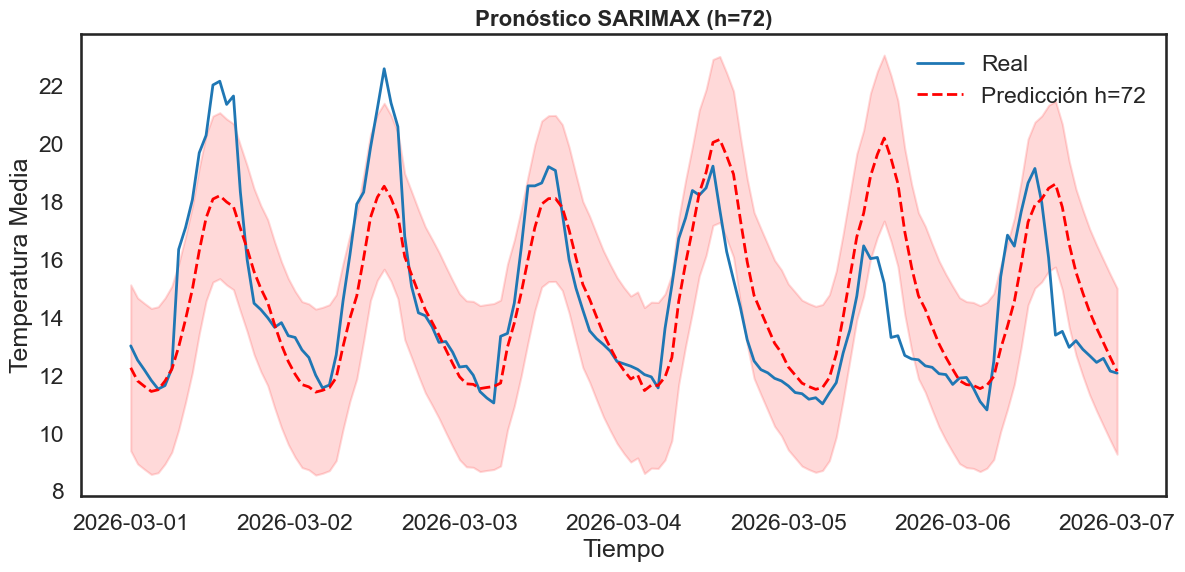

In [10]:
# Ejemplo: gráfico de una estación puntual.
estacion_ejemplo = df_pred_estaciones['estacion'].unique()[0]
grafico_predicciones_ci(
    df_pred_estaciones[df_pred_estaciones['estacion'] == estacion_ejemplo],
    modelo='sarimax',
    fecha_inicio="2026-03-01",
    fecha_fin="2026-03-07",
)

In [11]:
%%time
# Calcular métricas en distintos periodos
df_metricas_test_general = calcular_metricas(
    df_pred[(df_pred['fechaHora'] >= '2024-01-01') & (df_pred['fechaHora'] <= '2026-03-31')]
)

df_metricas_test_marzo = calcular_metricas(
    df_pred[(df_pred['fechaHora'] >= '2026-03-01') & (df_pred['fechaHora'] <= '2026-03-31')]
)

df_estaciones_metricas_test_general = calcular_metricas(
    df_pred_estaciones[(df_pred_estaciones['fechaHora'] >= '2024-01-01') & (df_pred_estaciones['fechaHora'] <= '2026-03-31')],
    estaciones=True
)

df_estaciones_test_marzo = calcular_metricas(
    df_pred_estaciones[(df_pred_estaciones['fechaHora'] >= '2026-03-01') & (df_pred_estaciones['fechaHora'] <= '2026-03-31')],
    estaciones=True
)

# Guardar todas las tablas en un solo Excel con diferentes hojas
with pd.ExcelWriter("../../results/modelosARIMA/prediciones/predicciones_metricas.xlsx", engine="openpyxl") as writer:
    df_metricas_test_general.to_excel(writer, sheet_name="General_Test", index=False)
    df_metricas_test_marzo.to_excel(writer, sheet_name="Marzo_Test", index=False)
    df_estaciones_metricas_test_general.to_excel(writer, sheet_name="General_Estaciones", index=False)
    df_estaciones_test_marzo.to_excel(writer, sheet_name="Marzo_Estaciones", index=False)

print("Metricas generadas correctamente")

Metricas generadas correctamente
CPU times: total: 1.33 s
Wall time: 1.47 s
